In [4]:
from langgraph.graph import StateGraph, START, END

In [9]:
from typing import TypedDict
# define a state 
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [10]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    state['bmi'] = round(weight / (height ** 2) , 2)
    return state

In [11]:
def label_bmi(state: BMIState) -> BMIState:
    if state['bmi'] < 18.5:
        state['category'] = "under weight"
    elif 18.5 <= state['bmi'] < 25:
        state['category'] = "normal weight"
    elif 25 <= state['bmi'] < 30:
        state['category'] = "over weight"
    else:
        state['category'] = "obese"
    
    return state

In [12]:
# define graph
graph = StateGraph(BMIState)

# add nodes
graph.add_node("calculate_bmi" , calculate_bmi)
graph.add_node("label_bmi" , label_bmi)

""" 
our graph scheme:
start -> calculate bmi -> label_bmi -> end
"""
# add edges
graph.add_edge(start_key = START , end_key = "calculate_bmi") # start -> calculate bmi
graph.add_edge(start_key = "calculate_bmi" , end_key = "label_bmi") # calculate bmi -> label_bmi
graph.add_edge(start_key = "label_bmi" , end_key = END)

# compile the graph 
workflow = graph.compile()

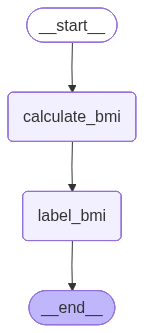

In [13]:
workflow

In [15]:
# excecute the graph workflow
initial_state = {
    "weight_kg" : 52,
    "height_m" : 1.73
}
final_state = workflow.invoke(initial_state)
final_state

{'weight_kg': 52, 'height_m': 1.73, 'bmi': 17.37, 'category': 'under weight'}